
## Poisson distribution — from first principles and with libraries.
 
    P(X = k) = (lambda^k * e^-lambda) / k!      for k = 0, 1, 2, ...
    E[X] = Var(X) = lambda

Poisson(lambda=3)  — from the formula
  k |   P(X=k)
----------------
  0 |   0.0498
  1 |   0.1494
  2 |   0.2240
  3 |   0.2240
  4 |   0.1680
  5 |   0.1008
  6 |   0.0504
  7 |   0.0216
  8 |   0.0081
  9 |   0.0027

mean  = 3.0
var   = 3.0
P(X <= 2) = 0.4232
P(X = 0)  = 0.0498

Empirical mean     = 2.997   (expect 3)
Empirical variance = 2.993   (expect 3)

Saved plot -> poisson.png


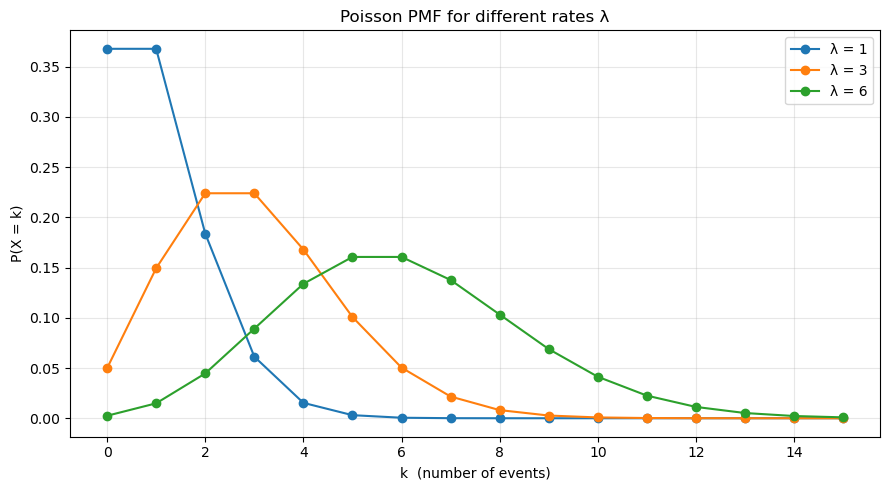

In [ ]:
import math
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
 
 
# ----------------------------------------------------------------------
# 1. The PMF computed straight from the definition (no libraries)
# ----------------------------------------------------------------------


def poisson_pmf(k, lam):
    """Probability of exactly k events when the average rate is lam."""
    return (lam ** k) * math.exp(-lam) / math.factorial(k)
 
 
lam = 3  # average events per interval
 
print(f"Poisson(lambda={lam})  — from the formula")
print(f"{'k':>3} | {'P(X=k)':>8}")
print("-" * 16)
for k in range(10):
    print(f"{k:>3} | {poisson_pmf(k, lam):>8.4f}")
 
 
# ----------------------------------------------------------------------
# 2. Same thing with scipy (what you'd actually use in practice)
# ----------------------------------------------------------------------
# scipy.stats.poisson.pmf matches our hand-rolled version exactly.


ks = np.arange(0, 10)
scipy_probs = poisson.pmf(ks, mu=lam)
 
# Handy extras scipy gives you for free:
print(f"\nmean  = {poisson.mean(mu=lam)}")          # -> lambda
print(f"var   = {poisson.var(mu=lam)}")             # -> lambda  (mean == variance)
print(f"P(X <= 2) = {poisson.cdf(2, mu=lam):.4f}")  # cumulative probability
print(f"P(X = 0)  = {poisson.pmf(0, mu=lam):.4f}")  # e^-lambda
 
 
# ----------------------------------------------------------------------
# 3. Simulate: draw samples and check mean ≈ variance ≈ lambda
# ----------------------------------------------------------------------


rng = np.random.default_rng(0)
samples = rng.poisson(lam=lam, size=100_000)
print(f"\nEmpirical mean     = {samples.mean():.3f}   (expect {lam})")
print(f"Empirical variance = {samples.var():.3f}   (expect {lam})")
 
 
# ----------------------------------------------------------------------
# 4. Plot the PMF for a few values of lambda
# ----------------------------------------------------------------------
plt.figure(figsize=(9, 5))
for l in (1, 3, 6):
    xs = np.arange(0, 16)
    plt.plot(xs, poisson.pmf(xs, mu=l), marker="o", label=f"λ = {l}")
 
plt.title("Poisson PMF for different rates λ")
plt.xlabel("k  (number of events)")
plt.ylabel("P(X = k)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("poisson.png", dpi=130)
print("\nSaved plot -> poisson.png")